# 02 · EDA — Transactions (Structured, Risk Classification)
Real dataset: 2,000 transactions, ~12% fraud rate, with pre-engineered risk flags (`velocity_flag`, `geo_anomaly_flag`, `high_amount_flag`, `is_international`).

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import load_transactions
from eda_utils import basic_profile, class_imbalance, numeric_summary, plot_category_counts

## 1. Load & profile

In [2]:
df = load_transactions()
basic_profile(df, 'transactions')

--- transactions ---
shape: (2000, 16)

dtypes:
transaction_id                  str
account_id                      str
timestamp            datetime64[us]
amount_inr                  float64
merchant_name                   str
merchant_category               str
transaction_type                str
city                            str
hour_of_day                   int64
day_of_week                     str
is_international               bool
velocity_flag                  bool
geo_anomaly_flag               bool
high_amount_flag               bool
fraud_label                   int64
fraud_reason                    str
dtype: object

null counts:
transaction_id          0
account_id              0
timestamp               0
amount_inr              0
merchant_name           0
merchant_category       0
transaction_type        0
city                    0
hour_of_day             0
day_of_week             0
is_international        0
velocity_flag           0
geo_anomaly_flag        0
high_amoun

## 2. Fraud class balance
~12% fraud, ~88% legitimate — imbalanced as expected for a real fraud dataset. `class_weight='balanced'` is used in the trained model (`src/risk_classifier.py`) to compensate.

             count   pct
fraud_label             
0             1756  87.8
1              244  12.2


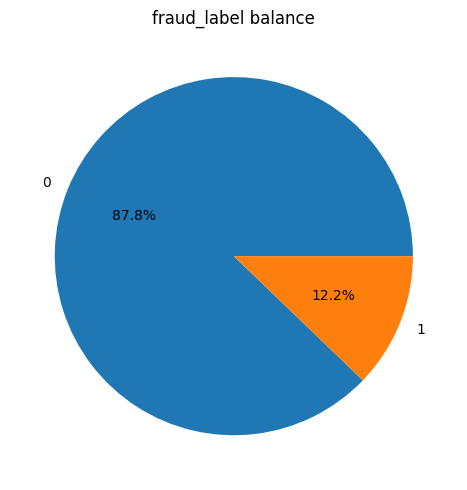

In [3]:
balance = class_imbalance(df, 'fraud_label')

## 3. Key finding: `is_international` and `geo_anomaly_flag` perfectly separate fraud
Every fraudulent transaction has `is_international = Yes` and `geo_anomaly_flag = Yes`; every legitimate transaction has both as `No` — a 100% clean split, no overlap. `velocity_flag` and `high_amount_flag` are strong but not perfect signals. This makes the classification task easy on *this* dataset (the trained fraud model gets ~100% test accuracy) — that's expected for a hand-engineered synthetic flag, not evidence the model will perform this well on live data where these flags are noisier and fraud doesn't sort so cleanly.

In [4]:
for col in ['is_international', 'geo_anomaly_flag', 'velocity_flag', 'high_amount_flag']:
    print(f'--- {col} ---')
    print(pd.crosstab(df[col], df['fraud_label']))
    print()

--- is_international ---
fraud_label          0    1
is_international           
False             1756    0
True                 0  244

--- geo_anomaly_flag ---
fraud_label          0    1
geo_anomaly_flag           
False             1756    0
True                 0  244

--- velocity_flag ---
fraud_label       0    1
velocity_flag           
False          1756   82
True              0  162

--- high_amount_flag ---
fraud_label          0    1
high_amount_flag           
False             1756  103
True                 0  141



## 4. Transaction amount by fraud label
Fraudulent transactions are ~9x larger on average (₹24.5K vs ₹2.8K median-adjacent) — amount alone is a meaningful, if imperfect, signal.

              count          mean           std     min         25%  \
fraud_label                                                           
0            1756.0   2815.829829   3738.218787   50.18    678.4325   
1             244.0  24544.401066  15377.467090  272.28  10664.6875   

                   50%         75%       max  
fraud_label                                   
0             1306.430   1980.0950  14999.40  
1            23887.625  38150.5975  49979.31  


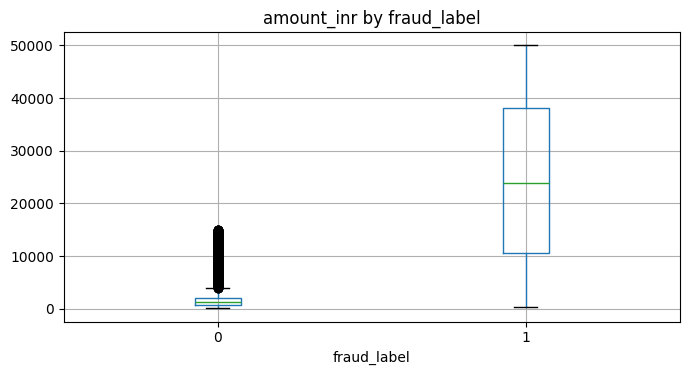

In [5]:
numeric_summary(df, 'amount_inr', by='fraud_label')

## 5. Time-of-day pattern
Fraud clusters at off-hours per `fraud_reason` (see below) — worth checking whether `hour_of_day` shows the same pattern independently of the explicit flags.

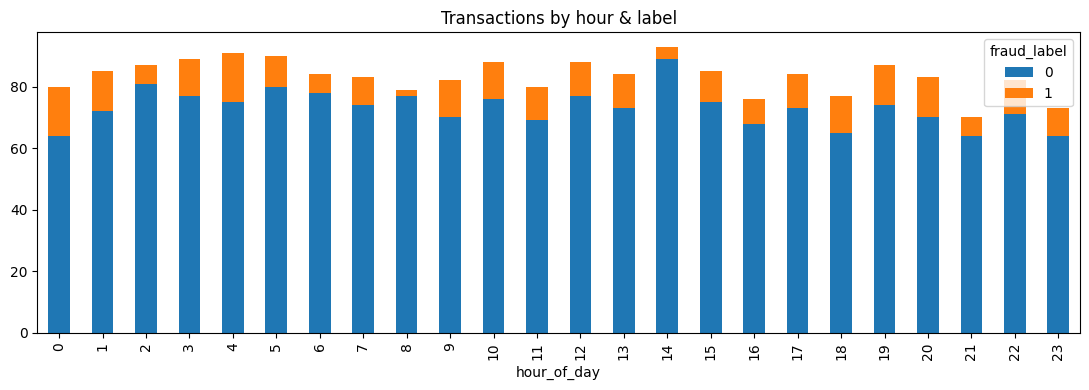

In [6]:
hourly = df.groupby(['hour_of_day', 'fraud_label']).size().unstack(fill_value=0)
hourly.plot(kind='bar', stacked=True, figsize=(11, 4), title='Transactions by hour & label')
plt.tight_layout(); plt.show()

## 6. City / merchant patterns

In [7]:
grp = df.groupby('city')['fraud_label'].agg(['count', 'mean']).rename(columns={'mean': 'fraud_rate'})
grp.sort_values('fraud_rate', ascending=False)

,count,fraud_rate
city,,
Dubai,38,1.0
Unknown,38,1.0
New York,49,1.0
Singapore,29,1.0
London,47,1.0
Kuala Lumpur,43,1.0
Hyderabad,198,0.0
Delhi,249,0.0
Chennai,211,0.0


In [8]:
df['fraud_reason'].value_counts()

fraud_reason
High amount         56
Location anomaly    55
Velocity breach     52
Unknown merchant    44
Off-hours           37
Name: count, dtype: int64

## 7. Transaction type & merchant category breakdown

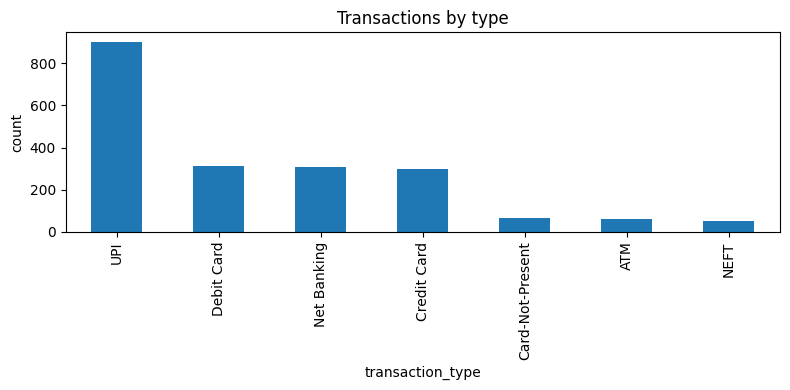

transaction_type
UPI                 902
Debit Card          312
Net Banking         309
Credit Card         299
Card-Not-Present     67
ATM                  61
NEFT                 50
Name: count, dtype: int64

In [9]:
plot_category_counts(df, 'transaction_type', title='Transactions by type')

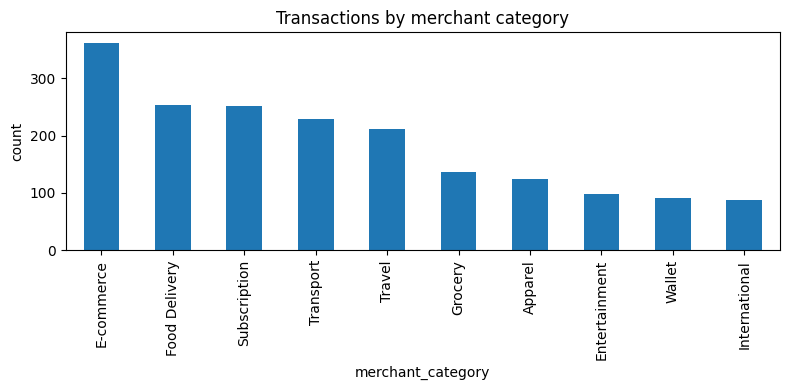

merchant_category
E-commerce       362
Food Delivery    253
Subscription     251
Transport        229
Travel           211
Grocery          136
Apparel          125
Entertainment     98
Wallet            91
International     88
Name: count, dtype: int64

In [10]:
plot_category_counts(df, 'merchant_category', title='Transactions by merchant category', top_n=10)

## 8. Takeaways
- ~12% fraud rate, clean data (no nulls except `fraud_reason`, which is expected — it's only populated for fraud cases).
- `is_international` + `geo_anomaly_flag` are perfect fraud separators in this dataset; `velocity_flag` and `high_amount_flag` are strong. A production model should treat this as an upper bound, not an expectation — real flag noise will be higher.
- Fraudulent transactions run ~9x larger than legitimate ones on average.
- The trained RandomForest fraud model (`src/risk_classifier.py`) reaches ~100% test accuracy given these features — a reflection of how separable the synthetic flags are, not a claim about live-data performance.